# Stock Market Data and Analysis

1. What stock price data looks like and how to load it
2. One simple tool to read price trends (Moving Average)
3. How to measure the tone of news headlines (Sentiment Analysis)


---
## Step 0 — Load the tools we need

In [16]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# yfinance  — free library to download stock price history
import yfinance as yf

# VADER    — sentiment analyser built for short financial/social media text
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# scipy    — for the Pearson correlation test
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded.')

All libraries loaded.


---
## Step 1 — What is the Stock Market?

The stock market is a place where people **buy and sell small pieces of ownership** in companies.  
Each piece is called a **share** (also called a stock or equity).

Every publicly listed company has a short code called a **ticker symbol**:

| Company | Ticker |
|---------|--------|
| Apple | `AAPL` |
| Tesla | `TSLA` |
| Google (Alphabet) | `GOOGL` |
| Amazon | `AMZN` |
| Microsoft | `MSFT` |

With one line of Python code we can download years of daily price history for any of these companies.

In [ ]:
# Download Apple daily price data for 2024
# auto_adjust=True means the prices are already corrected for stock splits and dividends
TICKER = 'AAPL'

df = yf.download(TICKER, start='2024-01-01', end='2024-11-30',
                 auto_adjust=True, progress=False)

# Fix column names (newer versions of yfinance add an extra label layer)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.sort_index()  # make sure dates go from oldest to newest

print(f'Downloaded {len(df)} trading days of {TICKER} data')
print(f'From {df.index[0].date()}  to  {df.index[-1].date()}')
print()
print('First 5 rows:')
df.head()

Downloaded 231 trading days of AAPL data
From 2024-01-02  to  2024-11-29

First 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,183.731308,186.502522,181.999301,185.225777,82488700
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500
2024-01-04,180.039658,181.207518,179.020249,180.277180,71983600
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700
2024-01-08,183.652145,183.691743,179.633891,180.217821,59144500


### What do these columns mean?

Each row = one **trading day** (markets are closed on weekends and holidays).

| Column | Meaning | Simple analogy |
|--------|---------|----------------|
| `Open` | Price when the market opened | Opening bid at an auction |
| `High` | Highest price paid that day | Peak price buyers were willing to pay |
| `Low` | Lowest price that day | The floor sellers accepted |
| `Close` | Price when the market closed | The final agreed price of the day |
| `Volume` | Number of shares that changed hands | How busy / active the day was |

This `Open-High-Low-Close-Volume` format is called **OHLCV** — the universal language of stock data.  
You will see it in every financial library, every CSV file, and every chart.

In [19]:
# Quick summary of the price data
print('=== AAPL 2024 — Key Statistics ===')
print(f"  Lowest closing price  : ${df['Close'].min():.2f}   on {df['Close'].idxmin().date()}")
print(f"  Highest closing price : ${df['Close'].max():.2f}   on {df['Close'].idxmax().date()}")
print(f"  Average closing price : ${df['Close'].mean():.2f}")


=== AAPL 2024 — Key Statistics ===
  Lowest closing price  : $163.51   on 2024-04-19
  Highest closing price : $236.04   on 2024-11-29
  Average closing price : $201.80


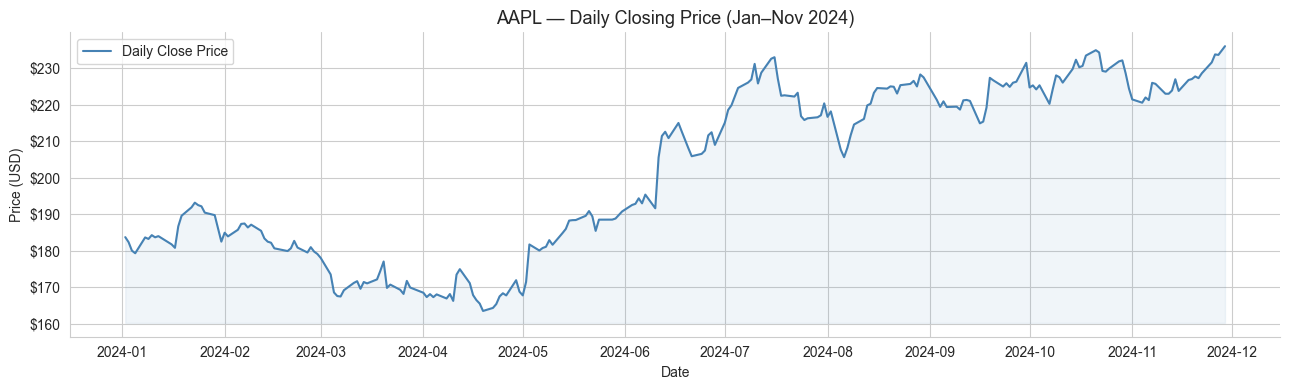

In [20]:
# Plot the closing price over time
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.5, label='Daily Close Price')

# Shade the area under the line to make the trend easier to see
ax.fill_between(df.index, df['Close'], df['Close'].min() * 0.98,
                alpha=0.08, color='steelblue')

ax.set_title(f'{TICKER} — Daily Closing Price (Jan–Nov 2024)', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# === INTERPRETATION (auto-generated from actual data) ===

start_price  = df['Close'].iloc[0]
end_price    = df['Close'].iloc[-1]
total_change = (end_price - start_price) / start_price * 100
direction    = 'went UP' if total_change > 0 else 'went DOWN'

# Find the single biggest drop and biggest gain in a single day
daily_returns = df['Close'].pct_change() * 100
worst_day     = daily_returns.idxmin()
best_day      = daily_returns.idxmax()

print('WHAT THE CHART TELLS US')
print('=' * 50)
print(f'  Start of 2024 price : ${start_price:.2f}')
print(f'  End of period price : ${end_price:.2f}')
print(f'  Overall change      : {total_change:+.1f}%  ({direction})')
print()
print(f'  Best single day : {best_day.date()}  (+{daily_returns[best_day]:.1f}%)')
print(f'  Worst single day: {worst_day.date()}  ({daily_returns[worst_day]:.1f}%)')
print()
if total_change > 10:
    print('  -> Strong upward trend. Investors who held AAPL did well in this period.')
elif total_change > 0:
    print('  -> Modest positive trend. The stock ended higher but with ups and downs.')
elif total_change > -10:
    print('  -> Slight downward trend. The stock ended a little lower than it started.')
else:
    print('  -> Significant decline. This period was tough for AAPL investors.')

WHAT THE CHART TELLS US
  Start of 2024 price : $183.73
  End of period price : $236.04
  Overall change      : +28.5%  (went UP)

  Best single day : 2024-06-11  (+7.3%)
  Worst single day: 2024-08-05  (-4.8%)

  -> Strong upward trend. Investors who held AAPL did well in this period.


---
## Step 2 — Reading the Trend: The Moving Average

Raw daily prices jump up and down a lot — it is hard to see the overall direction.  
A **Moving Average (MA)** smooths this out by replacing each day's price with the **average of the last N days**.

**Example — 20-day Simple Moving Average (SMA 20)**:  
The value on any day = the average closing price over the previous 20 trading days.

| SMA Position | What it means |
|-------------|---------------|
| Price **above** the SMA | Recent days are stronger than the average → **upward momentum** |
| Price **below** the SMA | Recent days are weaker than the average → **downward momentum** |
| Price **crossing above** the SMA | Potential **buy signal** (trend reversing upward) |
| Price **crossing below** the SMA | Potential **sell signal** (trend reversing downward) |

This is the most widely used concept in technical analysis. Everything else builds on this idea.

In [22]:
# Compute the 20-day Simple Moving Average
# window=20 means: for each row, average the 20 rows ending at that row
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# The first 19 rows will be NaN because we don't have enough history yet
print('Last 5 rows (Close vs SMA_20):')
print(df[['Close', 'SMA_20']].tail().round(2))

Last 5 rows (Close vs SMA_20):
Price        Close  SMA_20
Date                      
2024-11-22  228.62  225.61
2024-11-25  231.60  225.60
2024-11-26  233.78  225.68
2024-11-27  233.65  225.93
2024-11-29  236.04  226.51


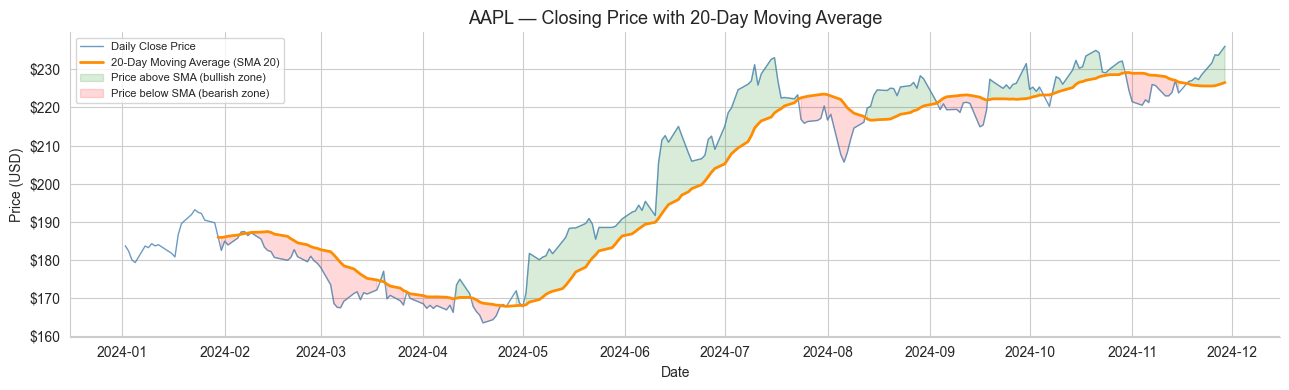

In [23]:
# Plot Close price with the SMA_20 overlaid
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(df.index, df['Close'],  color='steelblue', linewidth=1,
        alpha=0.8, label='Daily Close Price')
ax.plot(df.index, df['SMA_20'], color='darkorange', linewidth=2,
        label='20-Day Moving Average (SMA 20)')

# Highlight areas where price is above vs below the SMA
ax.fill_between(df.index, df['Close'], df['SMA_20'],
                where=(df['Close'] >= df['SMA_20']),
                alpha=0.15, color='green', label='Price above SMA (bullish zone)')
ax.fill_between(df.index, df['Close'], df['SMA_20'],
                where=(df['Close'] < df['SMA_20']),
                alpha=0.15, color='red', label='Price below SMA (bearish zone)')

ax.set_title(f'{TICKER} — Closing Price with 20-Day Moving Average', fontsize=13)
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
# === INTERPRETATION (auto-generated from actual data) ===

# How many days was price above vs below the SMA?
valid        = df.dropna(subset=['SMA_20'])   # drop the first 19 rows with no SMA yet
above_sma    = (valid['Close'] > valid['SMA_20']).sum()
below_sma    = (valid['Close'] <= valid['SMA_20']).sum()
pct_above    = above_sma / len(valid) * 100

last_close   = valid['Close'].iloc[-1]
last_sma     = valid['SMA_20'].iloc[-1]
current_pos  = 'ABOVE' if last_close > last_sma else 'BELOW'
gap_pct      = abs((last_close - last_sma) / last_sma * 100)

print('WHAT THE MOVING AVERAGE TELLS US')
print('=' * 50)
print(f'  Days price was ABOVE the 20-day SMA : {above_sma}  ({pct_above:.0f}% of the time)')
print(f'  Days price was BELOW the 20-day SMA : {below_sma}  ({100-pct_above:.0f}% of the time)')
print()
print(f'  Last close  : ${last_close:.2f}')
print(f'  SMA 20 now  : ${last_sma:.2f}')
print(f'  Price is currently {current_pos} the average by {gap_pct:.1f}%')
print()
if pct_above > 60:
    print(f'  -> AAPL spent most of this period above its 20-day average.')
    print(f'     This is a sign of sustained positive momentum — buyers were generally in control.')
elif pct_above > 40:
    print(f'  -> Price moved back and forth around the average.')
    print(f'     The market was indecisive — no clear dominant trend.')
else:
    print(f'  -> AAPL spent most of this period below its 20-day average.')
    print(f'     This signals sustained selling pressure during the period.')
print()
if current_pos == 'ABOVE':
    print(f'  -> At the end of the period: price is above the SMA — short-term trend is UP.')
else:
    print(f'  -> At the end of the period: price is below the SMA — short-term trend is DOWN.')

WHAT THE MOVING AVERAGE TELLS US
  Days price was ABOVE the 20-day SMA : 120  (57% of the time)
  Days price was BELOW the 20-day SMA : 92  (43% of the time)

  Last close  : $236.04
  SMA 20 now  : $226.51
  Price is currently ABOVE the average by 4.2%

  -> Price moved back and forth around the average.
     The market was indecisive — no clear dominant trend.

  -> At the end of the period: price is above the SMA — short-term trend is UP.


---
## Step 3 — Sentiment Analysis on News Headlines

**Sentiment analysis** reads a piece of text and decides whether it is **positive, negative, or neutral**.

In finance, the idea is simple:
- Positive headlines → investors feel confident → price might go up
- Negative headlines → investors feel worried → price might go down

We will use a tool called **VADER** (from the `nltk` library).  
VADER was designed specifically for short texts like news headlines and social media posts.  
It gives each text a **compound score** from **−1.0** (very negative) to **+1.0** (very positive).

| Compound score | Label |
|---------------|-------|
| ≥ 0.05 | Positive |
| ≤ −0.05 | Negative |
| Between −0.05 and 0.05 | Neutral |

### Our news dataset
100 sample headlines for AAPL, TSLA, GOOGL, AMZN, and MSFT — modelled on the **FNSPID** dataset students will use in the challenge.

In [25]:
# 100 sample news headlines — format: (headline, publisher, date, stock)
# Covers positive, negative, and neutral examples for each ticker

headlines_raw = [
    # ── AAPL — Positive ──────────────────────────────────────────────────────
    ('Apple reports record quarterly revenue beating analyst expectations by 8 percent',
     'Yahoo Finance', '2024-02-01', 'AAPL'),
    ('Warren Buffett increases Berkshire Hathaway stake in Apple to all-time high',
     'Reuters', '2024-02-15', 'AAPL'),
    ('Apple services revenue hits all-time high exceeding 23 billion this quarter',
     'Bloomberg', '2024-03-11', 'AAPL'),
    ('Apple announces 110 billion share buyback program its largest ever',
     'CNBC', '2024-05-02', 'AAPL'),
    ('Apple AI features drive record iPhone upgrade cycle in fourth quarter',
     'MarketWatch', '2024-08-20', 'AAPL'),
    ('Apple Vision Pro exceeds sales expectations in first full quarter on market',
     'TechCrunch', '2024-09-16', 'AAPL'),
    ('Apple stock hits new all-time high above 230 amid strong AI excitement',
     'WSJ', '2024-10-10', 'AAPL'),
    # ── AAPL — Negative ───────────────────────────────────────────────────────
    ('Apple faces major EU antitrust fine over App Store payment policies',
     'Reuters', '2024-03-04', 'AAPL'),
    ('Apple iPhone sales disappoint in China as Huawei regains market share',
     'Bloomberg', '2024-04-12', 'AAPL'),
    ('Analyst cuts Apple price target citing slowing wearables growth concerns',
     'Seeking Alpha', '2024-06-18', 'AAPL'),
    ('Apple gross margin falls short of Wall Street forecasts this quarter',
     'Financial Times', '2024-07-25', 'AAPL'),
    ('Apple production cuts signal weaker than expected holiday demand ahead',
     'Bloomberg', '2024-10-28', 'AAPL'),
    # ── AAPL — Neutral ────────────────────────────────────────────────────────
    ('Apple holds annual WWDC developer conference focused on AI integration',
     'Apple', '2024-06-10', 'AAPL'),
    ('Apple to release iOS 18 update with new accessibility and AI features',
     'MacRumors', '2024-09-09', 'AAPL'),
    ('Apple updates privacy policy ahead of EU Digital Markets Act compliance',
     'TechCrunch', '2024-01-25', 'AAPL'),
    ('Apple announces expansion of retail stores across Southeast Asian markets',
     'AppleInsider', '2024-04-03', 'AAPL'),
    ('Apple partners with major universities on artificial intelligence research',
     'Reuters', '2024-07-08', 'AAPL'),
    ('Apple files new patents for foldable iPhone and iPad product designs',
     'Patently Apple', '2024-08-05', 'AAPL'),
    ('Apple to hold earnings call for Q3 2024 results next Thursday after close',
     'Apple IR', '2024-07-30', 'AAPL'),
    ('Apple releases annual environmental progress report for current fiscal year',
     'Apple', '2024-05-20', 'AAPL'),
    # ── TSLA — Positive ───────────────────────────────────────────────────────
    ('Tesla delivers record 484000 vehicles in Q4 beating all analyst estimates',
     'Electrek', '2024-01-03', 'TSLA'),
    ('Tesla Cybertruck demand vastly exceeds production capacity in launch month',
     'Business Insider', '2024-01-18', 'TSLA'),
    ('Tesla energy storage deployments hit record high driven by utility contracts',
     'CleanTechnica', '2024-07-24', 'TSLA'),
    ('Tesla opens new Gigafactory in Mexico ahead of schedule and under budget',
     'Reuters', '2024-08-12', 'TSLA'),
    ('Tesla FSD subscription revenue grows 42 percent as autonomous features improve',
     'Not A Tesla App', '2024-09-23', 'TSLA'),
    # ── TSLA — Negative ───────────────────────────────────────────────────────
    ('Tesla misses Q1 delivery targets by 5.5 percent as EV competition intensifies',
     'CNBC', '2024-04-02', 'TSLA'),
    ('Tesla cuts Model 3 and Model Y prices for fifth time this year amid competition',
     'Electrek', '2024-04-22', 'TSLA'),
    ('Tesla Q2 profit margin shrinks to 14.6 percent its lowest level in four years',
     'WSJ', '2024-07-23', 'TSLA'),
    ('NHTSA opens investigation into Tesla vehicles over autopilot safety failures',
     'Reuters', '2024-06-05', 'TSLA'),
    ('Elon Musk sells 3.8 billion in Tesla stock raising leadership focus concerns',
     'Bloomberg', '2024-05-14', 'TSLA'),
    ('Tesla faces class action lawsuit over misleading range estimates for vehicles',
     'Reuters', '2024-08-30', 'TSLA'),
    # ── TSLA — Neutral ────────────────────────────────────────────────────────
    ('Tesla holds annual AI Day showcasing robotaxi and humanoid robot progress',
     'Teslarati', '2024-08-08', 'TSLA'),
    ('Tesla expands Supercharger network to 50000 stalls across 50 countries',
     'Electrek', '2024-03-15', 'TSLA'),
    ('Tesla to hire 10000 new manufacturing workers for Cybertruck production ramp',
     'Business Insider', '2024-02-20', 'TSLA'),
    ('Elon Musk outlines long-term autonomous vehicle and robotics vision at conference',
     'TechCrunch', '2024-06-25', 'TSLA'),
    ('Tesla releases Q3 2024 financial results and delivery report after market close',
     'Tesla IR', '2024-10-23', 'TSLA'),
    ('Tesla updates vehicle software with new entertainment and navigation features',
     'Not A Tesla App', '2024-01-30', 'TSLA'),
    ('Tesla announces new partnership with major battery materials supplier in Chile',
     'Reuters', '2024-07-03', 'TSLA'),
    ('Tesla to present at Goldman Sachs technology conference in San Francisco',
     'Goldman Sachs', '2024-09-10', 'TSLA'),
    ('Tesla invites media to first commercial Cybertruck production delivery event',
     'Teslarati', '2024-11-14', 'TSLA'),
    # ── GOOGL — Positive ──────────────────────────────────────────────────────
    ('Alphabet Q1 revenue hits 80.5 billion easily beating analyst expectations',
     'CNBC', '2024-04-25', 'GOOGL'),
    ('Google Cloud revenue accelerates to 28 percent growth reaccelerating from prior quarter',
     'TechCrunch', '2024-04-26', 'GOOGL'),
    ('Alphabet announces record 70 billion stock buyback program for shareholders',
     'Reuters', '2024-04-29', 'GOOGL'),
    ('YouTube advertising revenue grows 21 percent significantly ahead of expectations',
     'Bloomberg', '2024-07-29', 'GOOGL'),
    ('Google Gemini AI surpasses key benchmarks and gains strong enterprise adoption',
     'TechCrunch', '2024-09-04', 'GOOGL'),
    ('Google Search AI features drive advertising revenue to record quarterly high',
     'WSJ', '2024-10-29', 'GOOGL'),
    # ── GOOGL — Negative ──────────────────────────────────────────────────────
    ('DOJ antitrust trial threatens to break up Google search advertising monopoly',
     'Financial Times', '2024-01-17', 'GOOGL'),
    ('Alphabet announces 12000 layoffs as company restructures and cuts operating costs',
     'CNBC', '2024-01-22', 'GOOGL'),
    ('Google ad revenue misses estimates as TikTok gains digital advertising share',
     'WSJ', '2024-07-28', 'GOOGL'),
    ('EU regulators impose record 1.5 billion fine on Google for ad market abuse',
     'Reuters', '2024-03-14', 'GOOGL'),
    # ── GOOGL — Neutral ───────────────────────────────────────────────────────
    ('Google I/O developer conference scheduled for May 2024 in Mountain View',
     'Google', '2024-04-01', 'GOOGL'),
    ('Alphabet to report Q2 2024 earnings results after market close on Tuesday',
     'Alphabet IR', '2024-07-23', 'GOOGL'),
    ('Google announces expanded data center investment across Ohio and Virginia',
     'Google Cloud', '2024-02-08', 'GOOGL'),
    ('DeepMind publishes new research breakthrough in protein structure prediction',
     'DeepMind', '2024-05-15', 'GOOGL'),
    ('Google updates Maps with new AI-powered walking and public transit features',
     'Google Blog', '2024-06-12', 'GOOGL'),
    ('Alphabet names new CFO following senior leadership transition announcement',
     'Reuters', '2024-03-28', 'GOOGL'),
    ('Google releases comprehensive annual sustainability and environmental report',
     'Google', '2024-04-18', 'GOOGL'),
    ('Google partners with hospitals on AI-powered diagnostic imaging research',
     'Google Blog', '2024-08-22', 'GOOGL'),
    ('Google announces new privacy-first advertising technology to replace cookies',
     'Google Blog', '2024-09-30', 'GOOGL'),
    ('Alphabet joins industry coalition on responsible AI development standards',
     'Bloomberg', '2024-10-07', 'GOOGL'),
    # ── AMZN — Positive ───────────────────────────────────────────────────────
    ('Amazon Q4 earnings crush estimates with record 170 billion quarterly revenue',
     'CNBC', '2024-02-01', 'AMZN'),
    ('Amazon Web Services revenue growth reaccelerates to 17 percent beating expectations',
     'TechCrunch', '2024-02-02', 'AMZN'),
    ('Amazon Prime Day 2024 breaks all records with highest sales in program history',
     'Business Insider', '2024-07-18', 'AMZN'),
    ('Amazon Advertising surpasses 14 billion quarterly revenue for first time ever',
     'WSJ', '2024-07-25', 'AMZN'),
    ('Amazon raises minimum wage to 22 per hour improving workforce satisfaction scores',
     'Reuters', '2024-09-19', 'AMZN'),
    # ── AMZN — Negative ───────────────────────────────────────────────────────
    ('FTC antitrust lawsuit against Amazon advances as federal judge allows case',
     'Reuters', '2024-03-06', 'AMZN'),
    ('Amazon announces layoffs of 9000 employees in cloud and human resources divisions',
     'CNBC', '2024-01-11', 'AMZN'),
    ('Amazon AWS cloud growth disappoints as enterprise spending optimization continues',
     'Financial Times', '2024-04-30', 'AMZN'),
    ('Amazon Q1 guidance falls significantly short of analyst estimates shares fall',
     'MarketWatch', '2024-02-02', 'AMZN'),
    ('Amazon faces warehouse worker strikes across multiple US distribution locations',
     'Reuters', '2024-12-19', 'AMZN'),
    # ── AMZN — Neutral ────────────────────────────────────────────────────────
    ('Amazon Prime Day 2024 set for July 16-17 across 24 participating countries',
     'Amazon', '2024-06-27', 'AMZN'),
    ('Amazon to hire 250000 seasonal workers for peak holiday shopping season',
     'Business Insider', '2024-09-05', 'AMZN'),
    ('Amazon expands drone delivery to additional cities across Texas and North Carolina',
     'TechCrunch', '2024-07-02', 'AMZN'),
    ('AWS announces new data center region in Malaysia and New Zealand for 2025',
     'AWS', '2024-05-07', 'AMZN'),
    ('Amazon introduces new automated robotic fulfillment center technology nationwide',
     'Reuters', '2024-08-14', 'AMZN'),
    ('Jeff Bezos reduces Amazon stake through planned systematic share sale program',
     'Bloomberg', '2024-02-12', 'AMZN'),
    ('Amazon launches new health insurance product targeting small and medium businesses',
     'Healthcare IT News', '2024-09-24', 'AMZN'),
    ('Amazon partners with Stellantis for large electric delivery van fleet expansion',
     'Electrek', '2024-06-11', 'AMZN'),
    ('Amazon releases annual shareholder letter highlighting artificial intelligence strategy',
     'Amazon IR', '2024-04-11', 'AMZN'),
    ('AWS achieves new US government FedRAMP High cloud security authorization certification',
     'AWS', '2024-10-15', 'AMZN'),
    # ── MSFT — Positive ───────────────────────────────────────────────────────
    ('Microsoft Azure revenue surges 31 percent in Q2 significantly beating analyst estimates',
     'CNBC', '2024-01-30', 'MSFT'),
    ('Microsoft Copilot AI drives record enterprise software and cloud subscription growth',
     'TechCrunch', '2024-04-25', 'MSFT'),
    ('Microsoft raises quarterly dividend by 10 percent and expands share buyback authorization',
     'WSJ', '2024-09-16', 'MSFT'),
    ('Microsoft Teams reaches 320 million daily active users up 25 percent year over year',
     'Microsoft Blog', '2024-07-30', 'MSFT'),
    ('Microsoft gaming revenue jumps 61 percent following successful Activision Blizzard acquisition',
     'Reuters', '2024-01-31', 'MSFT'),
    ('Microsoft briefly becomes most valuable company in the world surpassing Apple market cap',
     'Bloomberg', '2024-01-12', 'MSFT'),
    # ── MSFT — Negative ───────────────────────────────────────────────────────
    ('Microsoft faces EU antitrust investigation over Teams and Office bundling practices',
     'Financial Times', '2024-02-22', 'MSFT'),
    ('Microsoft Azure growth slows to 28 percent below analyst consensus estimate of 31',
     'WSJ', '2024-07-30', 'MSFT'),
    ('Microsoft announces 10000 job cuts across all company divisions and geographies',
     'CNBC', '2024-01-16', 'MSFT'),
    ('Microsoft delays major Windows update disappointing enterprise upgrade customers',
     'Computerworld', '2024-06-04', 'MSFT'),
    # ── MSFT — Neutral ────────────────────────────────────────────────────────
    ('Microsoft Build developer conference kicks off in Seattle with AI announcements',
     'Microsoft', '2024-05-21', 'MSFT'),
    ('Microsoft releases monthly security patch bundle addressing 60 known vulnerabilities',
     'MSRC', '2024-03-12', 'MSFT'),
    ('Satya Nadella to speak at World Economic Forum annual meeting in Davos Switzerland',
     'WEF', '2024-01-15', 'MSFT'),
    ('Microsoft releases annual environmental sustainability progress and impact report',
     'Microsoft', '2024-05-30', 'MSFT'),
    ('Microsoft updates Office 365 pricing structure for enterprise tier customers in 2025',
     'Microsoft Blog', '2024-06-19', 'MSFT'),
    ('Microsoft acquires AI safety startup to bolster responsible AI development efforts',
     'TechCrunch', '2024-08-28', 'MSFT'),
    ('Microsoft announces new gaming subscription bundle offering for Xbox platform users',
     'Xbox News', '2024-09-03', 'MSFT'),
    ('Microsoft partners with EU governments on digital skills and workforce training programs',
     'Microsoft News', '2024-10-02', 'MSFT'),
    ('Microsoft cloud compliance certification approved for healthcare HIPAA regulated sector',
     'Azure', '2024-07-11', 'MSFT'),
    ('Microsoft to report Q1 FY2025 earnings results after market close on Wednesday',
     'Microsoft IR', '2024-10-29', 'MSFT'),
]

# Build a DataFrame that matches the FNSPID schema
news_df = pd.DataFrame(headlines_raw, columns=['headline', 'publisher', 'date', 'stock'])
news_df['date'] = pd.to_datetime(news_df['date'])

print(f'News dataset: {len(news_df)} headlines')
print(f'Tickers    : {sorted(news_df["stock"].unique())}')
print(f'Date range : {news_df["date"].min().date()}  to  {news_df["date"].max().date()}')
print()
print('Sample rows:')
news_df.sample(5, random_state=1)[['headline', 'publisher', 'date', 'stock']]

News dataset: 100 headlines
Tickers    : ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']
Date range : 2024-01-03  to  2024-12-19

Sample rows:


,headline,publisher,date,stock
80,Microsoft Azure revenue surges 31 percent in Q...,CNBC,2024-01-30,MSFT
84,Microsoft gaming revenue jumps 61 percent foll...,Reuters,2024-01-31,MSFT
33,Tesla to hire 10000 new manufacturing workers ...,Business Insider,2024-02-20,TSLA
81,Microsoft Copilot AI drives record enterprise ...,TechCrunch,2024-04-25,MSFT
93,Microsoft releases annual environmental sustai...,Microsoft,2024-05-30,MSFT


In [26]:
# Apply VADER to every headline and store the compound score
sia = SentimentIntensityAnalyzer()

# vader_compound is a number from -1.0 (very negative) to +1.0 (very positive)
news_df['vader_compound'] = news_df['headline'].apply(
    lambda text: sia.polarity_scores(text)['compound']
)

# Classify each score into a label using the standard VADER thresholds
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

news_df['sentiment'] = news_df['vader_compound'].apply(classify_sentiment)

# Show a few examples to build intuition
print('Examples — Highest scoring headlines (most positive):')
print(news_df.nlargest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))
print()
print('Examples — Lowest scoring headlines (most negative):')
print(news_df.nsmallest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

Examples — Highest scoring headlines (most positive):
                                                                         headline stock  vader_compound sentiment
           Apple stock hits new all-time high above 230 amid strong AI excitement  AAPL          0.7579  Positive
Amazon raises minimum wage to 22 per hour improving workforce satisfaction scores  AMZN          0.7506  Positive
   Google Gemini AI surpasses key benchmarks and gains strong enterprise adoption GOOGL          0.6908  Positive

Examples — Lowest scoring headlines (most negative):
                                                                        headline stock  vader_compound sentiment
      EU regulators impose record 1.5 billion fine on Google for ad market abuse GOOGL         -0.6808  Negative
   Tesla faces class action lawsuit over misleading range estimates for vehicles  TSLA         -0.5574  Negative
Microsoft delays major Windows update disappointing enterprise upgrade customers  MSFT         -0

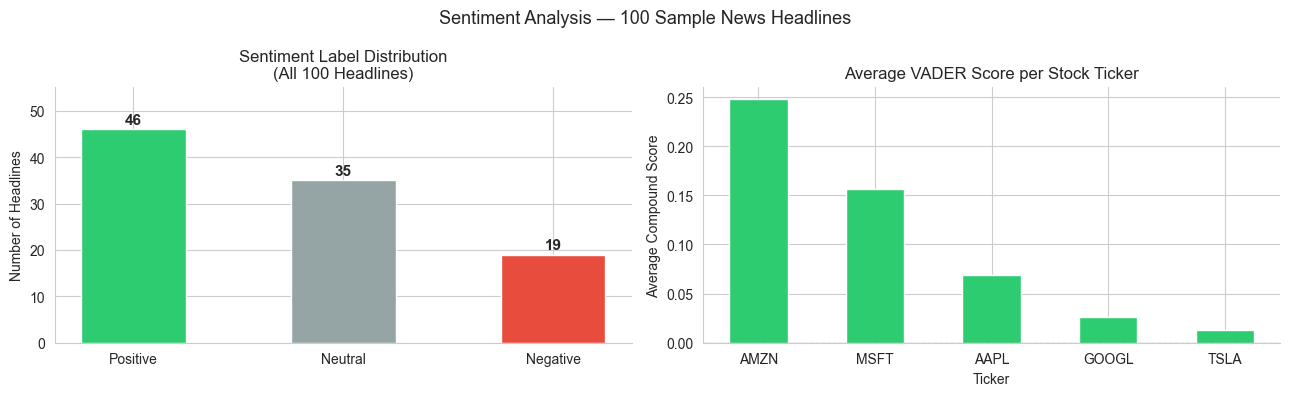

In [27]:
# Visualise sentiment across the dataset
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Chart 1: Overall label distribution ---
counts = news_df['sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
bar_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=bar_colors,
                   edgecolor='white', width=0.5)
# Add count labels on top of bars
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Sentiment Label Distribution\n(All 100 Headlines)', fontsize=12)
axes[0].set_ylabel('Number of Headlines')
axes[0].set_ylim(0, counts.max() * 1.2)

# --- Chart 2: Average sentiment score per ticker ---
avg_by_ticker = news_df.groupby('stock')['vader_compound'].mean().sort_values(ascending=False)
tick_colors   = ['#2ecc71' if v > 0 else '#e74c3c' for v in avg_by_ticker]
axes[1].bar(avg_by_ticker.index, avg_by_ticker.values, color=tick_colors,
            edgecolor='white', width=0.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average VADER Score per Stock Ticker', fontsize=12)
axes[1].set_ylabel('Average Compound Score')
axes[1].set_xlabel('Ticker')

plt.suptitle('Sentiment Analysis — 100 Sample News Headlines', fontsize=13)
plt.tight_layout()
plt.show()

In [29]:
# === INTERPRETATION (auto-generated from actual scores) ===

counts     = news_df['sentiment'].value_counts()
n_pos      = counts.get('Positive', 0)
n_neg      = counts.get('Negative', 0)
n_neu      = counts.get('Neutral',  0)
pct_pos    = n_pos / len(news_df) * 100
pct_neg    = n_neg / len(news_df) * 100

most_pos_ticker  = news_df.groupby('stock')['vader_compound'].mean().idxmax()
most_neg_ticker  = news_df.groupby('stock')['vader_compound'].mean().idxmin()
most_pos_score   = news_df.groupby('stock')['vader_compound'].mean().max()
most_neg_score   = news_df.groupby('stock')['vader_compound'].mean().min()

top_headline = news_df.loc[news_df['vader_compound'].idxmax(), 'headline']
bot_headline = news_df.loc[news_df['vader_compound'].idxmin(), 'headline']
top_score    = news_df['vader_compound'].max()
bot_score    = news_df['vader_compound'].min()

print('WHAT THE SENTIMENT ANALYSIS TELLS US')
print('=' * 60)
print(f'  Positive headlines : {n_pos}  ({pct_pos:.0f}%)')
print(f'  Neutral headlines  : {n_neu}  ({100 - pct_pos - pct_neg:.0f}%)')
print(f'  Negative headlines : {n_neg}  ({pct_neg:.0f}%)')
print()
print(f'  Most positive ticker : {most_pos_ticker}  (avg score: {most_pos_score:+.3f})')
print(f'  Most negative ticker : {most_neg_ticker}  (avg score: {most_neg_score:+.3f})')
print()
print(f'  Highest scored headline (score = {top_score:+.3f}):')
print(f'    "{top_headline}"')
print()
print(f'  Lowest scored headline (score = {bot_score:+.3f}):')
print(f'    "{bot_headline}"')


WHAT THE SENTIMENT ANALYSIS TELLS US
  Positive headlines : 46  (46%)
  Neutral headlines  : 35  (35%)
  Negative headlines : 19  (19%)

  Most positive ticker : AMZN  (avg score: +0.248)
  Most negative ticker : TSLA  (avg score: +0.013)

  Highest scored headline (score = +0.758):
    "Apple stock hits new all-time high above 230 amid strong AI excitement"

  Lowest scored headline (score = -0.681):
    "EU regulators impose record 1.5 billion fine on Google for ad market abuse"
